In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [4]:
ws_dict = fn.load_reanalysis_wind_speed(FILEPATH)

In [5]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Intensity-duration-frequency (IDF) analysis

Alternatively to setting an arbitrary threshold, plot IDF curves to see impact of varying the wind speed threshold (intensity), rolling average period (duration) and return period (frequency).

In [6]:
def daily_to_annual_prob(p_daily, days_per_year=365):
    """
    Convert daily exceedance probability to annual exceedance probability.
    Assumes independence between days.
    """
    return 1 - (1 - p_daily)**days_per_year

def annual_prob_to_return_period(p_annual):
    """
    Convert annual exceedance probability to return period (in years).
    """
    return 1 / p_annual

def return_period_to_annual_prob(T):
    """
    Convert return period (years) to annual exceedance probability.
    """
    return 1 / T

def annual_to_daily_prob(p_annual, days_per_year=365):
    """
    Convert annual exceedance probability to daily exceedance probability.
    """
    return 1 - (1 - p_annual)**(1 / days_per_year)

def daily_prob_to_return_period(p_daily, days_per_year=365):
    """
    Convert daily exceedance probability directly to return period (years).
    """
    p_annual = daily_to_annual_prob(p_daily, days_per_year)
    return annual_prob_to_return_period(p_annual)

def return_period_to_daily_prob(T, days_per_year=365):
    """
    Convert return period (years) directly to daily exceedance probability.
    """
    p_annual = return_period_to_annual_prob(T)
    return annual_to_daily_prob(p_annual, days_per_year)

Calculate rolling mean time series

In [7]:
ws_roll_dict = {}
for k, v in ws_dict.items():
    # var_name = list(v.data_vars)[0]
    # da = v[var_name].expand_dims({"window_len": [1]})
    da = v.expand_dims({"window_len": [1]})
    
    da_list = [da]

    # for roll in [2, 3, 4, 5, 7, 10, 14, 21, 30]:
    for roll in range(2, 31):
        da_roll = da.rolling(time=roll).mean()
        # da[var_name+"_roll"+str(roll)] = da_roll
        da_roll = da_roll.assign_coords({"window_len": [roll]})
        da_list.append(da_roll)
    
    ws_roll_dict[k] = xr.concat(da_list, dim="window_len")

In [8]:
def drought_intensity(da, freq, dim="time"):
    da = da.dropna("time")
    return da.where(da < da.quantile(freq, "time")).max("time")

In [9]:
def _idf_plot(
    ax,
    roll_da_list,
    q_freqs,
    legend_labels=None,
    ls_labels=None,
    colors=["tab:blue", "tab:orange", "tab:green", "tab:pink", "k", "tab:grey"]
):
    # fig, ax = plt.subplots(1, 1, figsize=(7,5))

    # markers = ["o", "s", "^", "v", "x", "d"]
    linestyles = ["-", "--"]
    
    for c, q in zip(
        colors,
        q_freqs
    ):  
        for da, ls in zip(roll_da_list, linestyles):
            ax.plot(
                da.window_len,
                drought_intensity(da, q),
                color=c,
                ls=ls,
                # label=str(q)
                )
    # Common legend
    if legend_labels is None:
        legend_labels = [str(np.round(q, 3)) for q in q_freqs]
    legend_colors = colors[:len(q_freqs)]
    legend_lines = [
        Line2D(
            [], [], color=legend_colors[i], linestyle=linestyles[0], label=legend_labels[i]
        ) for i in range(len(q_freqs))
    ]
    # ax.legend(handles=legend_lines, loc="lower right")
    
    # Legend for second set of data
    if len(roll_da_list) == 2:
        legend2_lines = [
            Line2D(
                [], [], color="gray", linestyle=linestyles[i], label=ls_labels[i]
            ) for i in range(2)
        ]
        legend_lines.append(legend2_lines[0])
        legend_lines.append(legend2_lines[1])
    ax.legend(handles=legend_lines, loc="lower right")

In [10]:
def plot_idf(roll_da_list, q_freqs, legend_labels=None, ls_labels=None):
    fig, ax = plt.subplots(1, 1, figsize=(7,5))
    _idf_plot(ax, roll_da_list, q_freqs, legend_labels, ls_labels)
        
    ax.set_xlabel("Duration [d]")
    ax.set_ylabel("Wind speed intensity [m/s]")
    ax.set_title("Intensity vs duration vs frequency")
    ax.set_yticks(np.arange(1, 10.1, 0.5))

In [11]:
def idf_surface_daily(roll_da, thresholds):
    """
    roll_da: rolling averaged daily values (DataArray with time and window_len dimension)
    thresholds: list/array of wind speed thresholds (m/s)
    """
    results = []

    for d in roll_da.window_len.values:
        # empirical CDF for each threshold
        probs = [(roll_da.sel(window_len=d) <= thr).mean().item() for thr in thresholds]
        results.append(probs)

    return xr.DataArray(
        np.array(results), 
        coords={"window_len": roll_da.window_len.values, "threshold": thresholds},
        dims=["window_len", "threshold"]
    )

In [12]:
def _add_contour(ax, roll_da, levels=[0.01, 0.05, 0.1], colors="white", ls="-", labels=None):
    cs = ax.contour(
        roll_da.window_len,
        roll_da.threshold,
        roll_da.T,
        levels=levels,
        colors=colors,
        linestyles=ls
    )
    if isinstance(labels, list):
        fmt = {}
        for l, s in zip(cs.levels, labels):
            fmt[l] = s
        ax.clabel(cs, fmt=fmt)
    elif labels is None:
        pass
    elif labels == "%":
        
        def fmt(x):
            s = f"{x*100:.1f}"
            if s.endswith("0"):
                s = f"{x*100:.0f}"
            return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
        
        ax.clabel(cs, fmt=fmt)
    else:
        fmt="%.3f"
        ax.clabel(cs, fmt=fmt)

In [13]:
import matplotlib

In [14]:
def plot_idf_surface(
    ax,
    roll_da_list,
    q_freqs,
    legend_labels=None,
    ls_labels=None,
    colors=["tab:blue", "tab:orange", "tab:green", "tab:pink", "k", "tab:grey"],
    extra_legend=False
):
    THRESHOLDS = np.arange(0, 10.1, 0.05)
    
    idf_surface = idf_surface_daily(
        roll_da_list[0],
        THRESHOLDS
    )
    idf_surface.plot(
        ax=ax,
        x="window_len",
        cmap="viridis",
        # norm=matplotlib.colors.LogNorm(vmin=0.01, vmax=1),
        vmin=0,
        vmax=1,
        cbar_kwargs={"label": "Probability [-]"}
    )
    ax.set_xlim(1, 30)
    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.set_xticks([1, 5, 10, 20, 30])
    
    _add_contour(
        ax,
        idf_surface,
        levels=q_freqs,
        colors=colors,
        labels=legend_labels
    )

    if extra_legend: # Custom legend for colored lines
        legend_lines2 = [
            Line2D(
                [], [], color=colors[i], linestyle="-", label='{:.1%}'.format(q_freqs[i])
            ) for i in range(len(q_freqs))
        ]
        
        legend = ax.legend(handles=legend_lines2, loc=(-0, -0.), ncols=4, facecolor="lightgray", fontsize=10)
        ax.add_artist(legend)

    if len(roll_da_list) == 2:
        idf_surface_2 = idf_surface_daily(
            roll_da_list[1],
            THRESHOLDS
        )
        
        _add_contour(
            ax,
            idf_surface_2,
            levels=q_freqs,
            colors=colors,
            labels=None,
            ls="--"
        )
        
        # Legend for ls
        linestyles = ["-", "--"]
        legend_lines = [
            Line2D(
                [], [], color="k", linestyle=linestyles[i], label=ls_labels[i]
            ) for i in range(2)
        ]
        ax.legend(handles=legend_lines, loc="lower right", fontsize=8)

In [15]:
rp_probs = return_period_to_daily_prob(np.array([3, 5, 10]))
rp_probs

array([0.00111025, 0.00061117, 0.00028862])

In [16]:
FREQUENCY_QUANTILES = np.append(
    np.array([0.9, 0.5, 0.1, 0.01, 1/365, 1/(365*3)]),
    rp_probs
)[[0, 1, 2, 3, 4]]
# FREQUENCY_QUANTILES = rp_probs
FREQUENCY_QUANTILES

array([0.9       , 0.5       , 0.1       , 0.01      , 0.00273973])

In [17]:
daily_prob_to_return_period(FREQUENCY_QUANTILES)

array([1.        , 1.        , 1.        , 1.02618618, 1.58071508])

Text(0.5, 0, 'Averaging period [d]')

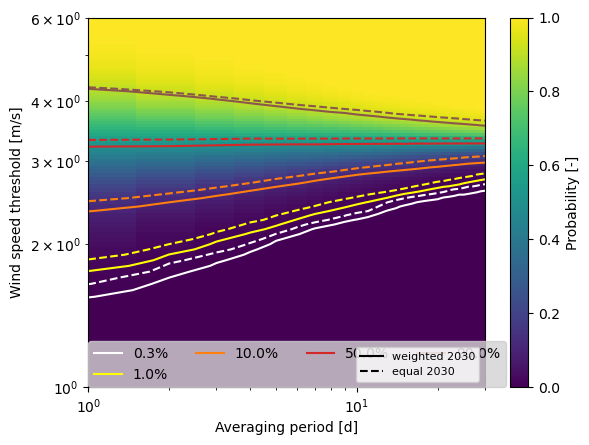

In [23]:
fig, ax = plt.subplots(1, 1)

plot_idf_surface(
    ax,
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2030_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2030_unweighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["weighted 2030", "equal 2030"],
    colors=["w", "yellow", "tab:orange", "tab:red", "tab:brown"],
    # colors=["tab:pink"", "cyan", "tab:blue", "tab:green"]
    extra_legend=True
)

ax.set_ylim(1, 6)
ax.set_ylabel("Wind speed threshold [m/s]")
ax.set_xlabel("Averaging period [d]")

In [20]:
IDF_COLORS = ["w", "yellow", "tab:orange", "tab:red", "tab:brown"]

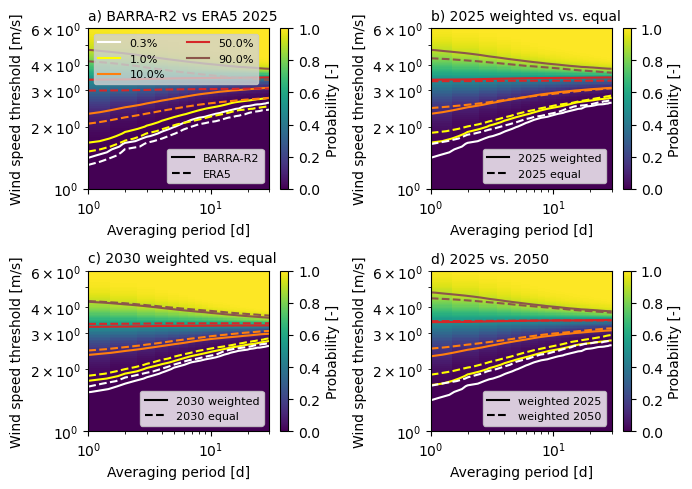

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))

# rp_labels = ["3 yr", "5 yr", "10 yr"]
legend_lines2 = [
    Line2D(
        [], [], color=IDF_COLORS[i], linestyle="-", label='{:.1%}'.format(FREQUENCY_QUANTILES[::-1][i])
    ) for i in range(len(FREQUENCY_QUANTILES))
]

legend = ax[0,0].legend(handles=legend_lines2, loc="upper left", ncols=2, facecolor="lightgray", fontsize=8)
ax[0,0].add_artist(legend)

# ERA5 vs BARRA-R2
plot_idf_surface(
    ax[0,0],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["ERA5_NEM_NEM_wind_2025_weighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["BARRA-R2", "ERA5"],
    colors=IDF_COLORS
)
ax[0,0].set_title("a) BARRA-R2 vs ERA5 2025", loc="left", fontsize=10)

# Weighted vs unweighted
plot_idf_surface(
    ax[0,1],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["2025 weighted", "2025 equal"],
    colors=IDF_COLORS
)
ax[0,1].set_title("b) 2025 weighted vs. equal", loc="left", fontsize=10)

# 2030 weighted vs unweighted
plot_idf_surface(
    ax[1,0],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2030_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2030_unweighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["2030 weighted", "2030 equal"],
    colors=IDF_COLORS
)
ax[1,0].set_title("c) 2030 weighted vs. equal", loc="left", fontsize=10)

# 2025 vs 2050 weighted
plot_idf_surface(
    ax[1,1],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["weighted 2025", "weighted 2050"],
    colors=IDF_COLORS
)
ax[1,1].set_title("d) 2025 vs. 2050", loc="left", fontsize=10)

for a in ax.flatten():
    a.set_ylim(1, 6)
    a.set_ylabel("Wind speed threshold [m/s]")
    a.set_xlabel("Averaging period [d]")

plt.tight_layout()

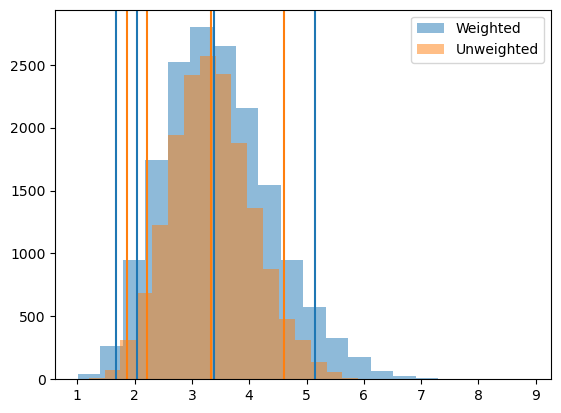

In [100]:
L = 1

fig, ax = plt.subplots(1, 1)

da1 = ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"].sel(window_len=L)
da2 = ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"].sel(window_len=L)

_ = ax.hist(da1, 20, color="tab:blue", alpha=0.5, label="Weighted", zorder=0)
_ = ax.hist(da2, 20, color="tab:orange", alpha=0.5, label="Unweighted", zorder=1)
for q in [0.01, 0.05, 0.5, 0.95]:
    ax.axvline(da1.quantile(q, "time"), color="tab:blue")
    ax.axvline(da2.quantile(q, "time"), color="tab:orange")
ax.legend()

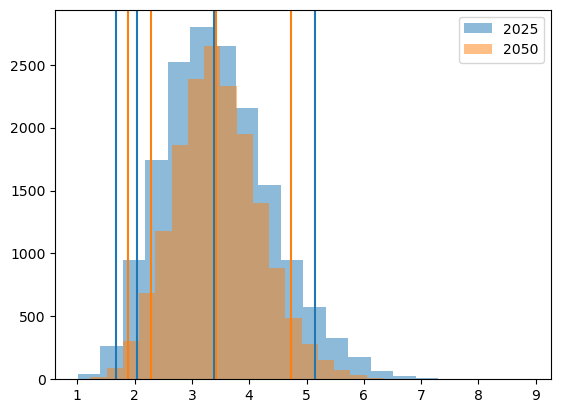

In [101]:
L = 1

fig, ax = plt.subplots(1, 1)

da1 = ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"].sel(window_len=L)
da2 = ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"].sel(window_len=L)

_ = ax.hist(da1, 20, color="tab:blue", alpha=0.5, label="2025", zorder=0)
_ = ax.hist(da2, 20, color="tab:orange", alpha=0.5, label="2050", zorder=1)
for q in [0.01, 0.05, 0.5, 0.95]:
    ax.axvline(da1.quantile(q, "time"), color="tab:blue")
    ax.axvline(da2.quantile(q, "time"), color="tab:orange")
ax.legend()

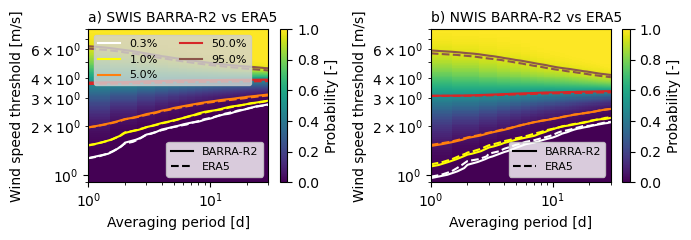

In [139]:
fig, ax = plt.subplots(1, 2, figsize=(7,2.5))

# rp_labels = ["3 yr", "5 yr", "10 yr"]
legend_lines2 = [
    Line2D(
        [], [], color=IDF_COLORS[i], linestyle="-", label='{:.1%}'.format(FREQUENCY_QUANTILES[::-1][i])
    ) for i in range(len(FREQUENCY_QUANTILES))
]

legend = ax[0].legend(handles=legend_lines2, loc="upper left", ncols=2, facecolor="lightgray", fontsize=8)
ax[0].add_artist(legend)

# SWIS
plot_idf_surface(
    ax[0],
    [
        ws_roll_dict["BARRA-R2_SWIS"],
        ws_roll_dict["ERA5_SWIS"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["BARRA-R2", "ERA5"],
    colors=IDF_COLORS
)
ax[0].set_title("a) SWIS BARRA-R2 vs ERA5", loc="left", fontsize=10)

# SWIS
plot_idf_surface(
    ax[1],
    [
        ws_roll_dict["BARRA-R2_NWIS"],
        ws_roll_dict["ERA5_NWIS"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["BARRA-R2", "ERA5"],
    colors=IDF_COLORS
)
ax[1].set_title("b) NWIS BARRA-R2 vs ERA5", loc="left", fontsize=10)

for a in ax.flatten():
    a.set_ylim(0.9, 8)
    a.set_ylabel("Wind speed threshold [m/s]")
    a.set_xlabel("Averaging period [d]")

plt.tight_layout()

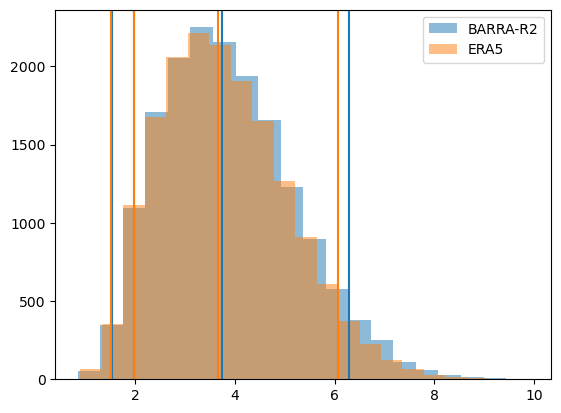

In [103]:
L = 1

fig, ax = plt.subplots(1, 1)

da1 = ws_roll_dict["BARRA-R2_SWIS"].sel(window_len=L)
da2 = ws_roll_dict["ERA5_SWIS"].sel(window_len=L)

_ = ax.hist(da1, 20, color="tab:blue", alpha=0.5, label="BARRA-R2", zorder=0)
_ = ax.hist(da2, 20, color="tab:orange", alpha=0.5, label="ERA5", zorder=1)
for q in [0.01, 0.05, 0.5, 0.95]:
    ax.axvline(da1.quantile(q, "time"), color="tab:blue")
    ax.axvline(da2.quantile(q, "time"), color="tab:orange")
ax.legend()

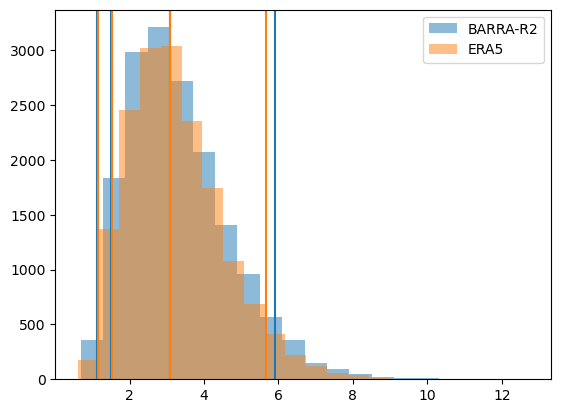

In [104]:
L = 1

fig, ax = plt.subplots(1, 1)

da1 = ws_roll_dict["BARRA-R2_NWIS"].sel(window_len=L)
da2 = ws_roll_dict["ERA5_NWIS"].sel(window_len=L)

_ = ax.hist(da1, 20, color="tab:blue", alpha=0.5, label="BARRA-R2", zorder=0)
_ = ax.hist(da2, 20, color="tab:orange", alpha=0.5, label="ERA5", zorder=1)
for q in [0.01, 0.05, 0.5, 0.95]:
    ax.axvline(da1.quantile(q, "time"), color="tab:blue")
    ax.axvline(da2.quantile(q, "time"), color="tab:orange")
ax.legend()